In [1]:
import pandas as pd

df = pd.read_csv("Uber.csv")

df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   START_DATE*  1156 non-null   object 
 1   END_DATE*    1155 non-null   object 
 2   CATEGORY*    1155 non-null   object 
 3   START*       1155 non-null   object 
 4   STOP*        1155 non-null   object 
 5   MILES*       1156 non-null   float64
 6   PURPOSE*     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [4]:
df.describe()

,MILES*
count,1156.000000
mean,21.115398
std,359.299007
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,12204.700000


In [5]:
df.shape

(1156, 7)

In [6]:
df.columns = df.columns.str.replace('*','', regex=False)

df.columns

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE'],
      dtype='object')

In [7]:
df.isnull().sum()

START_DATE      0
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64

In [8]:
import warnings 
warnings.filterwarnings('ignore')

In [9]:
df['PURPOSE'].fillna("Not Specified", inplace=True)

In [10]:
df[df.duplicated()]

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
492,6/28/2016 23:34,6/28/2016 23:59,Business,Durham,Cary,9.9,Meeting


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df[df.duplicated()]

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE


In [13]:
df.describe()

,MILES
count,1155.000000
mean,21.125108
std,359.454497
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,12204.700000


 ### For non numerical

In [14]:
df.describe(include = ['object'])

,START_DATE,END_DATE,CATEGORY,START,STOP,PURPOSE
count,1155,1154,1154,1154,1154,1155
unique,1155,1154,2,177,188,11
top,01-01-2016 21:11,01-01-2016 21:17,Business,Cary,Cary,Not Specified
freq,1,1,1077,201,202,503


In [15]:
df.drop(df.index[-1],inplace = True)

In [16]:
df['START_DATE']=pd.to_datetime(df['START_DATE'],errors = 'coerce')

In [17]:
df['END_DATE']=pd.to_datetime(df['END_DATE'],errors = 'coerce')

In [18]:
df.dtypes

START_DATE    datetime64[ns]
END_DATE      datetime64[ns]
CATEGORY              object
START                 object
STOP                  object
MILES                float64
PURPOSE               object
dtype: object

In [19]:
from datetime import datetime

In [20]:
df['Hour'] = df['START_DATE'].dt.hour
df['Day'] = df['START_DATE'].dt.day
df['Month'] = df['START_DATE'].dt.month
df['Weekday'] = df['START_DATE'].dt.day_name()

In [21]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,Hour,Day,Month,Weekday
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.0,1.0,1.0,Friday
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Not Specified,1.0,2.0,1.0,Saturday
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,20.0,2.0,1.0,Saturday
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,17.0,5.0,1.0,Tuesday
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,14.0,6.0,1.0,Wednesday


# Create Trip Duration Feature

In [22]:
df['Trip_Duration'] = (df['END_DATE'] - df['START_DATE']).dt.total_seconds() / 60

In [23]:
df = df[df['Trip_Duration'] > 0]

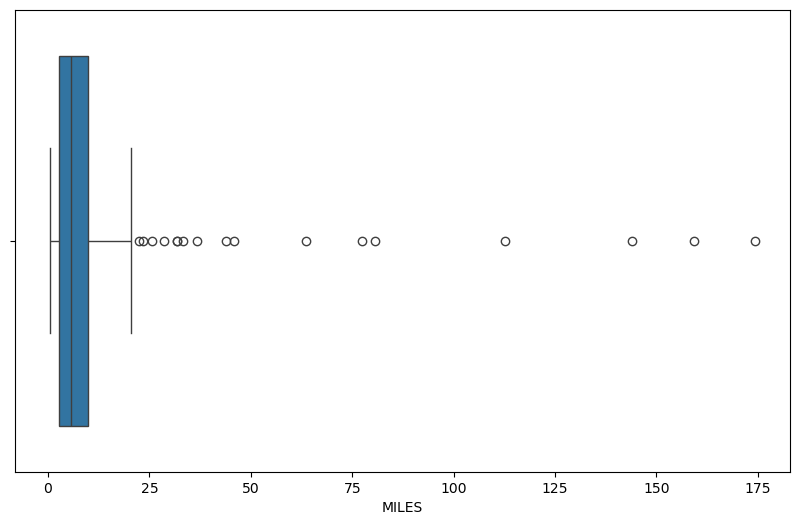

In [27]:
plt.figure(figsize = (10,6))
sns.boxplot(x=df['MILES'])
plt.show()

In [26]:
df = df[df['MILES'] < 200]

# Ride Demand by Hour

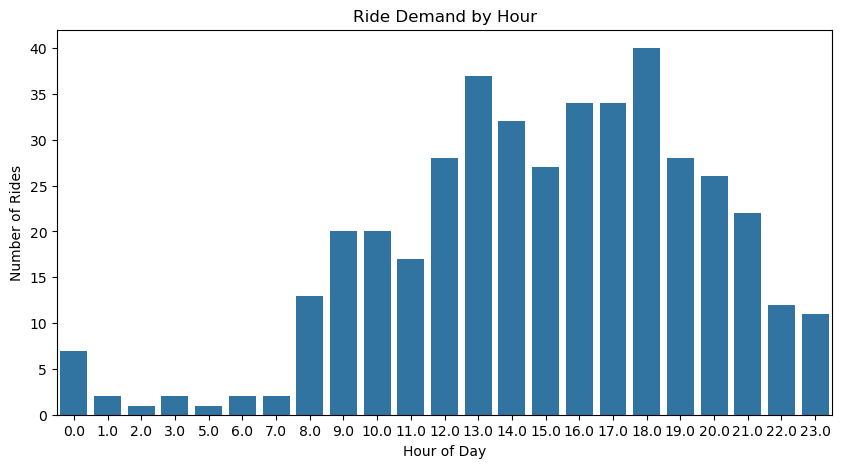

In [28]:
plt.figure(figsize=(10,5))
sns.countplot(x='Hour', data=df)
plt.title("Ride Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.show()

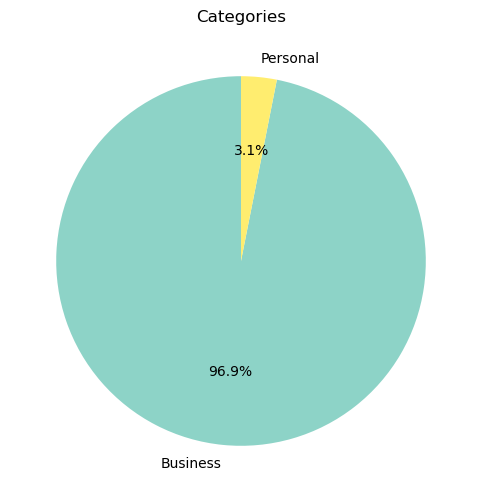

In [57]:
plt.figure(figsize=(10,6))

df['CATEGORY'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    cmap='Set3'
)

plt.title('Categories')
plt.ylabel('')
plt.show()

# Ride Demand by Weekday

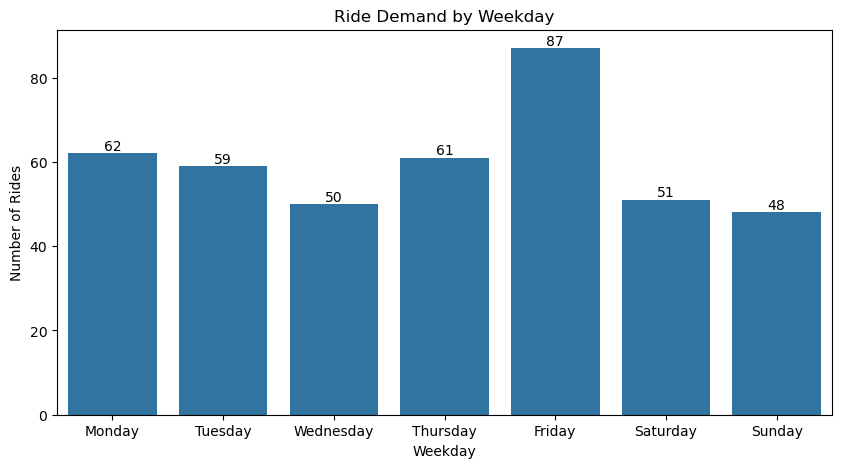

In [59]:
plt.figure(figsize=(10,5))

order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

ax = sns.countplot(x='Weekday', data=df, order=order_days)

# Add annotations
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', 
        va='bottom',
        fontsize=10
    )

plt.title("Ride Demand by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Rides")

plt.show()

# Ride Demand by Month

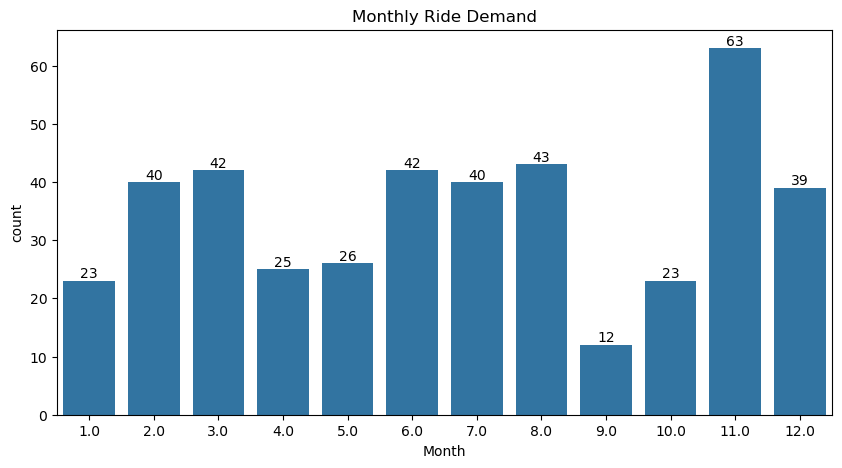

In [61]:
plt.figure(figsize=(10,5))
ax = sns.countplot(x='Month', data=df)
# Add annotations
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', 
        va='bottom',
        fontsize=10
    )
plt.title("Monthly Ride Demand")
plt.show()

# Trip Distance Distribution

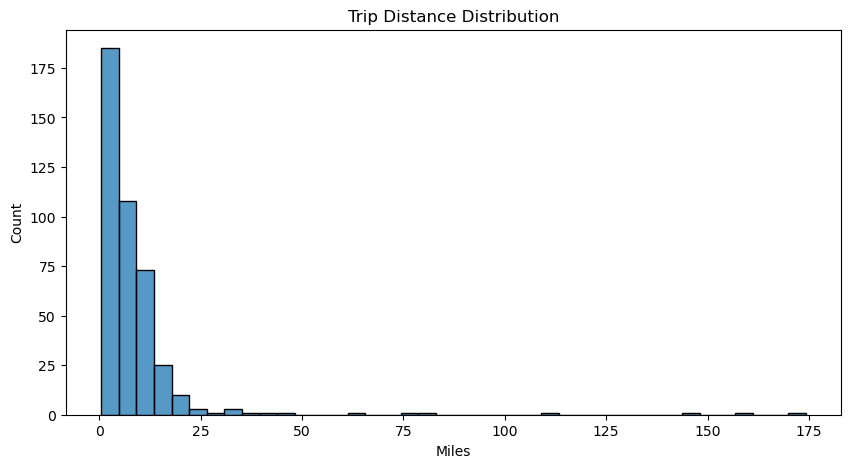

In [31]:
plt.figure(figsize=(10,5))
sns.histplot(df['MILES'], bins=40)
plt.title("Trip Distance Distribution")
plt.xlabel("Miles")
plt.show()

# Trip Duration Distribution

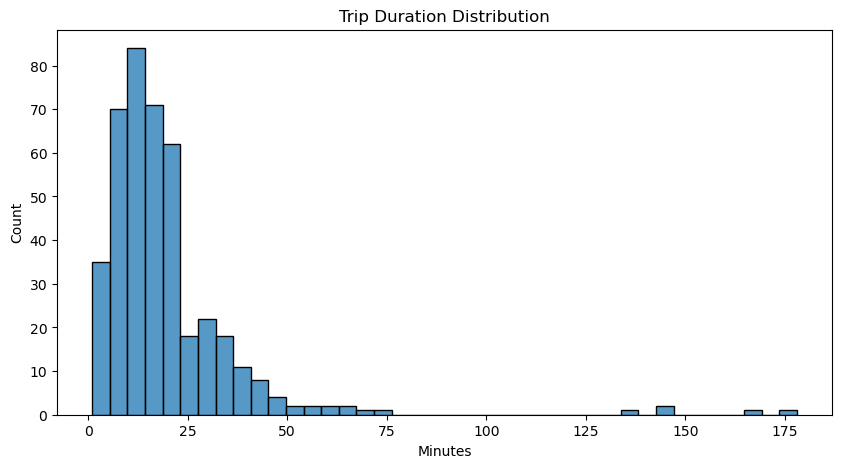

In [32]:
plt.figure(figsize=(10,5))
sns.histplot(df['Trip_Duration'], bins=40)
plt.title("Trip Duration Distribution")
plt.xlabel("Minutes")
plt.show()

# Ride Purpose Analysis

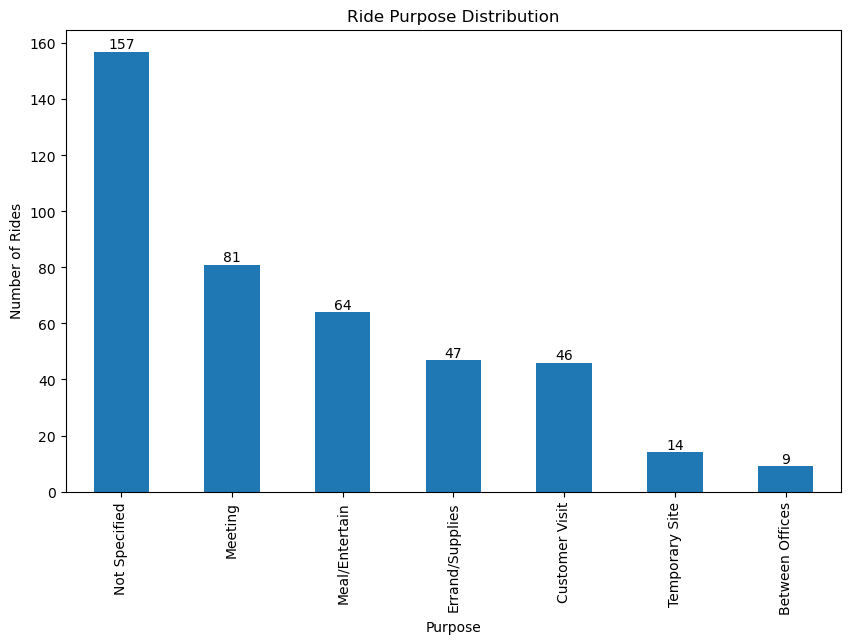

In [62]:
plt.figure(figsize=(10,6))
ax = df['PURPOSE'].value_counts().plot(kind='bar')
# Add annotations
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', 
        va='bottom',
        fontsize=10
    )
plt.title("Ride Purpose Distribution")
plt.xlabel("Purpose")
plt.ylabel("Number of Rides")
plt.show()

# Category Analysis (Business vs Personal)

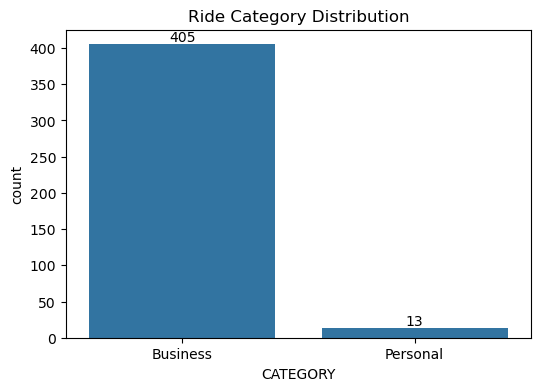

In [63]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='CATEGORY', data=df)
# Add annotations
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', 
        va='bottom',
        fontsize=10
    )
plt.title("Ride Category Distribution")
plt.show()


# Heatmap of Ride Demand

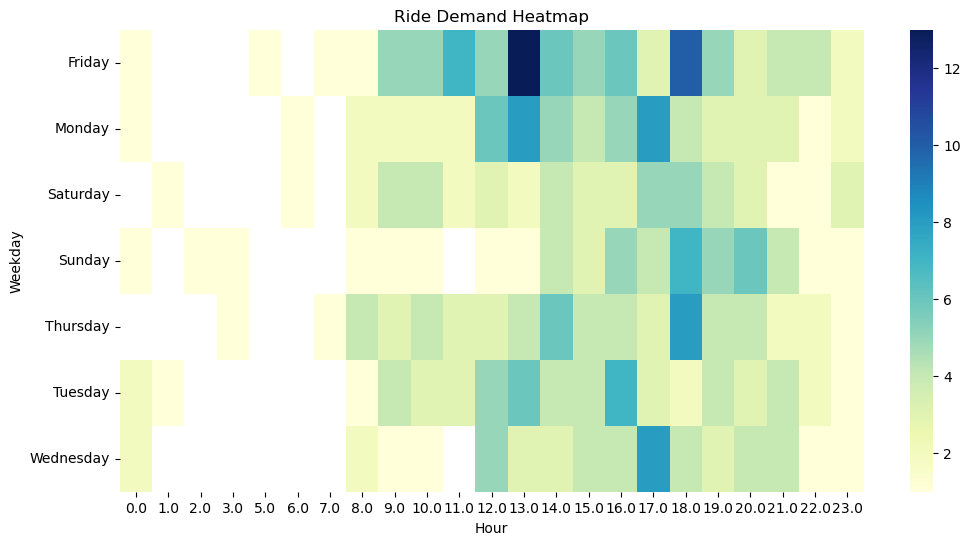

In [35]:
pivot = df.groupby(['Weekday','Hour']).size().unstack()

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Ride Demand Heatmap")
plt.show()

# Ride Start Location Analysis

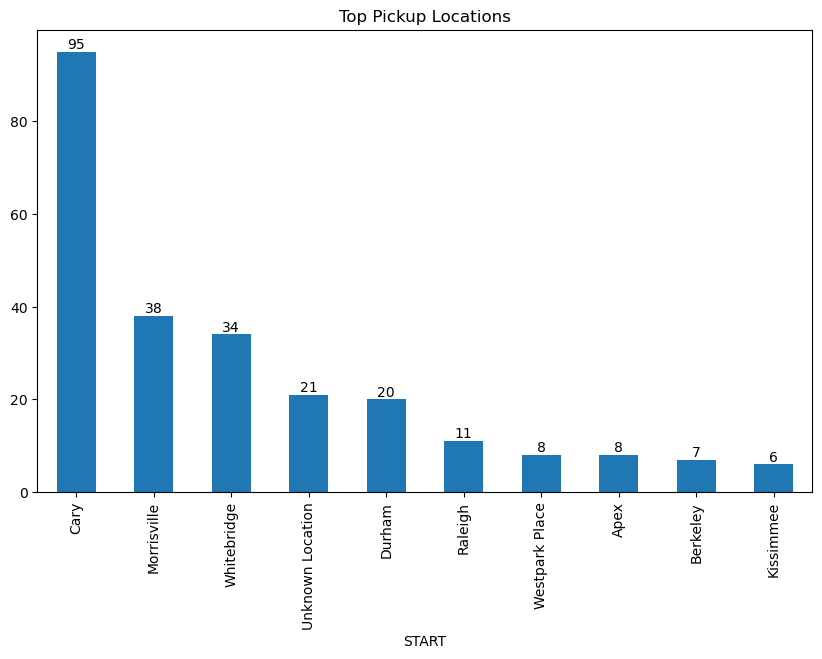

In [64]:
top_locations = df['START'].value_counts().head(10)

plt.figure(figsize=(10,6))
ax = top_locations.plot(kind='bar')
# Add annotations
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', 
        va='bottom',
        fontsize=10
    )
plt.title("Top Pickup Locations")
plt.show()


# Ride Stop Location Analysis

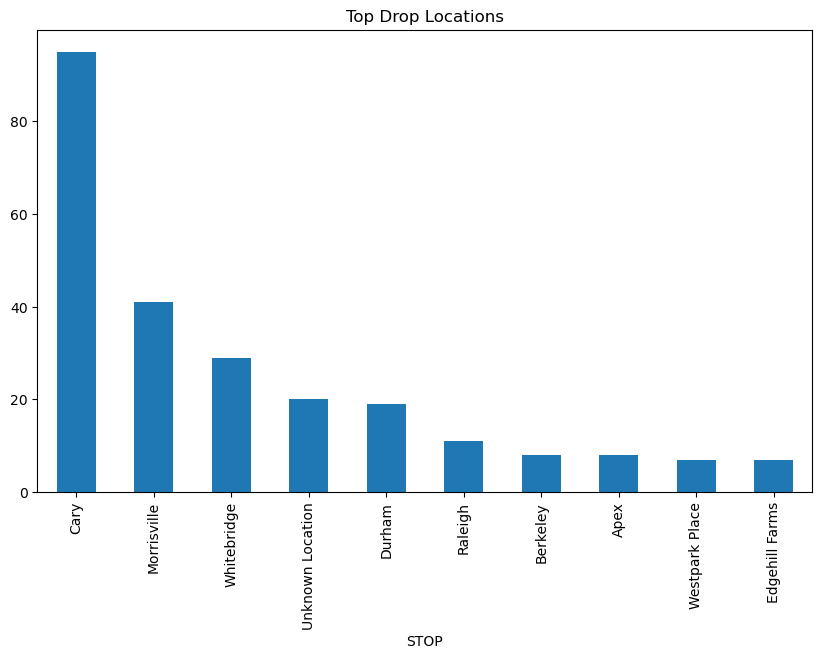

In [39]:
top_drop = df['STOP'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_drop.plot(kind='bar')
plt.title("Top Drop Locations")
plt.show()


# Correlation Analysis

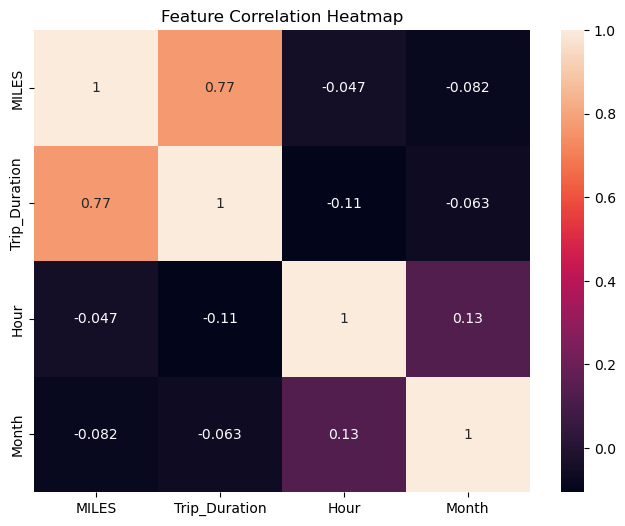

In [40]:
corr = df[['MILES','Trip_Duration','Hour','Month']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

# Detect Anomalies (Outliers)

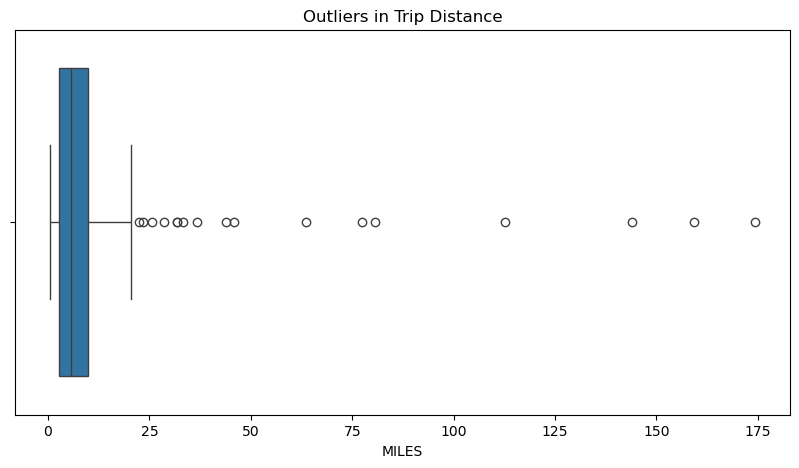

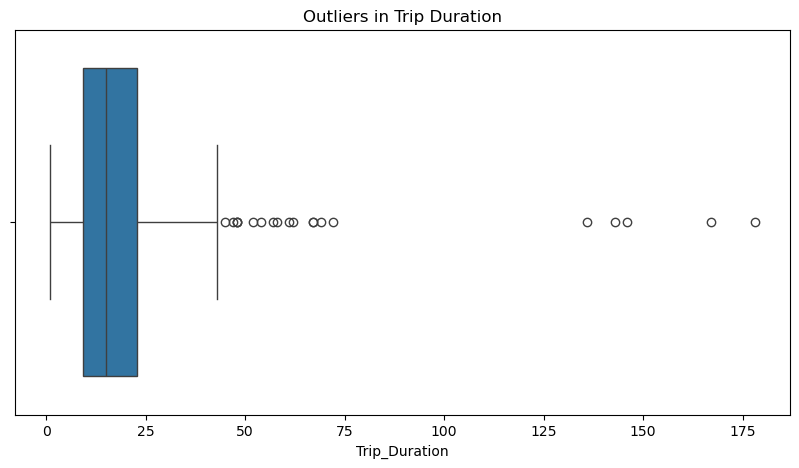

In [41]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['MILES'])
plt.title("Outliers in Trip Distance")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x=df['Trip_Duration'])
plt.title("Outliers in Trip Duration")
plt.show()

# Pricing Trend Approximation

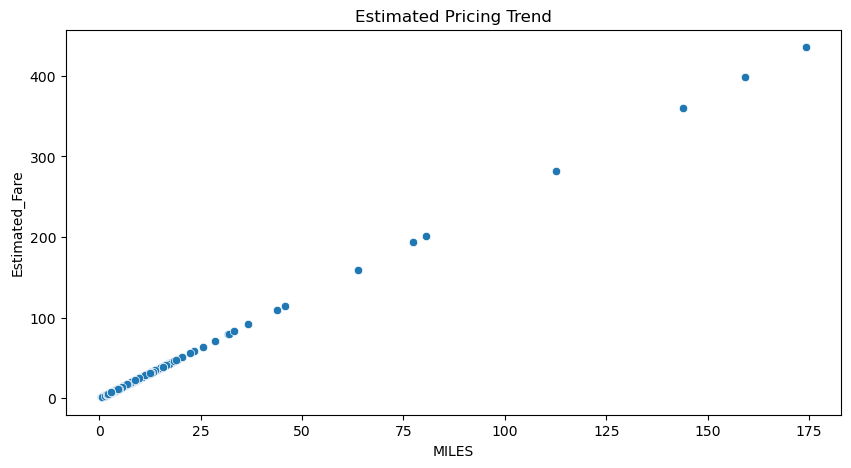

In [42]:
# Assume price proportional to distance

df['Estimated_Fare'] = df['MILES'] * 2.5

plt.figure(figsize=(10,5))
sns.scatterplot(x='MILES', y='Estimated_Fare', data=df)
plt.title("Estimated Pricing Trend")
plt.show()


# Peak Hour Analysis

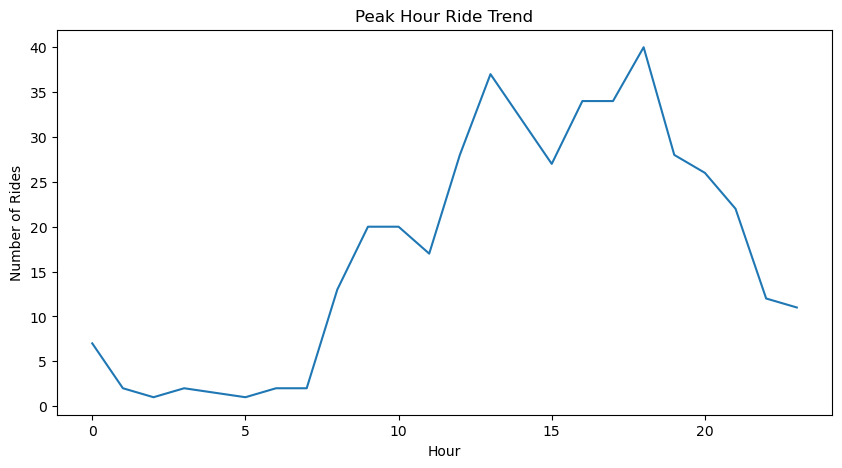


Peak Hour Ride Counts
Hour
0.0      7
1.0      2
2.0      1
3.0      2
5.0      1
6.0      2
7.0      2
8.0     13
9.0     20
10.0    20
11.0    17
12.0    28
13.0    37
14.0    32
15.0    27
16.0    34
17.0    34
18.0    40
19.0    28
20.0    26
21.0    22
22.0    12
23.0    11
Name: count, dtype: int64


In [43]:
peak_hours = df['Hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
peak_hours.plot()
plt.title("Peak Hour Ride Trend")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.show()

print("\nPeak Hour Ride Counts")
print(peak_hours)


# Ride Demand Dataset for Prediction

In [45]:
demand = df.groupby(['Hour','Month']).size().reset_index(name='Ride_Count')

#  Machine Learning Model
 Predict Ride Demand

In [47]:
from sklearn.model_selection import train_test_split

In [53]:
# Import required libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Features and target
X = demand[['Hour','Month']]
y = demand['Ride_Count']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = RandomForestRegressor()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [50]:
from sklearn.metrics import mean_squared_error

# Model Evaluation

In [54]:
mse = mean_squared_error(y_test,predictions)

print("\nModel Mean Squared Error:",mse)


Model Mean Squared Error: 5.31120909090909


# Visualization of Prediction

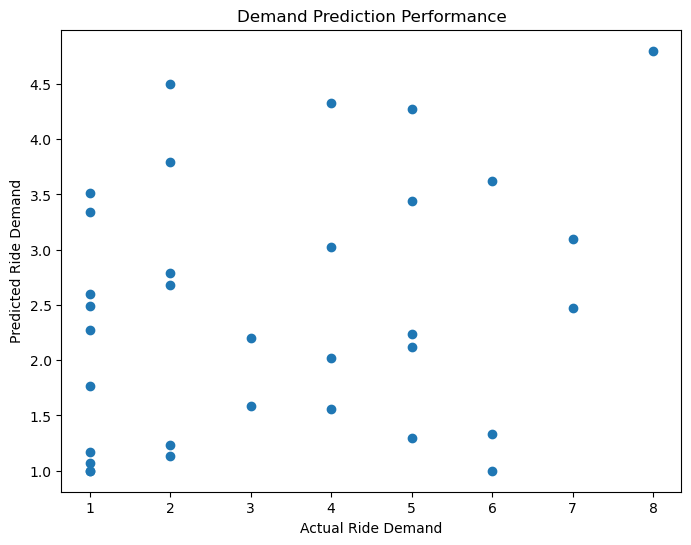

In [55]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,predictions)
plt.xlabel("Actual Ride Demand")
plt.ylabel("Predicted Ride Demand")
plt.title("Demand Prediction Performance")
plt.show()